In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
df = pd.read_csv('AirPassengers.csv', index_col='Month', parse_dates=True)
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [63]:
df.columns = ["passengers"]
df.head()

,passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<AxesSubplot:xlabel='Month'>

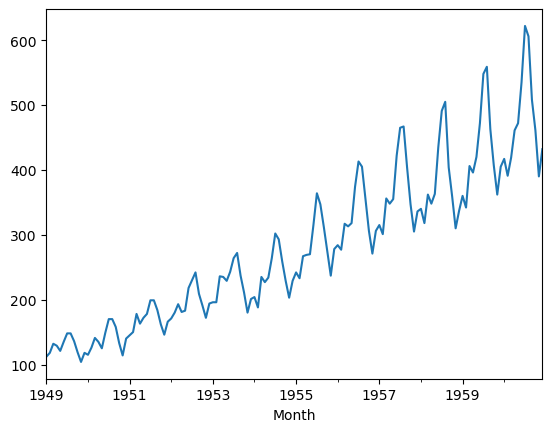

In [64]:
df['passengers'].plot()

In [65]:
import plotly.express as px

In [66]:
fig = px.line(df, y="passengers")
fig.update_layout(plot_bgcolor='white')
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title=''
)
fig.show()

In [67]:
import pmdarima as pmd

# AUTO-ARIMA

In [68]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [69]:
model = pmd.auto_arima(train, error_action='ignore', trace=True, supress_warning=True, seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.27 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.25 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.25 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.09 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=0.74 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.27 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.99 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=0.17 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=0.39 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.13 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=0.28 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC

In [70]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Sat, 14 Oct 2023   AIC                            905.686
Time:                                    11:36:34   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [71]:
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

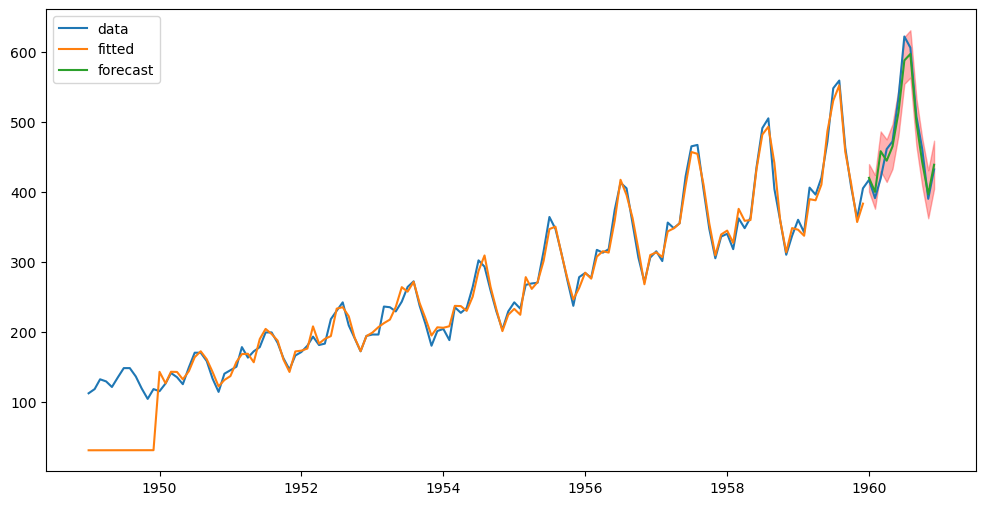

In [72]:
train_pred = model.predict_in_sample(start=0, end=-1)

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df.index, df['passengers'], label='data')
ax.plot(train.index, train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

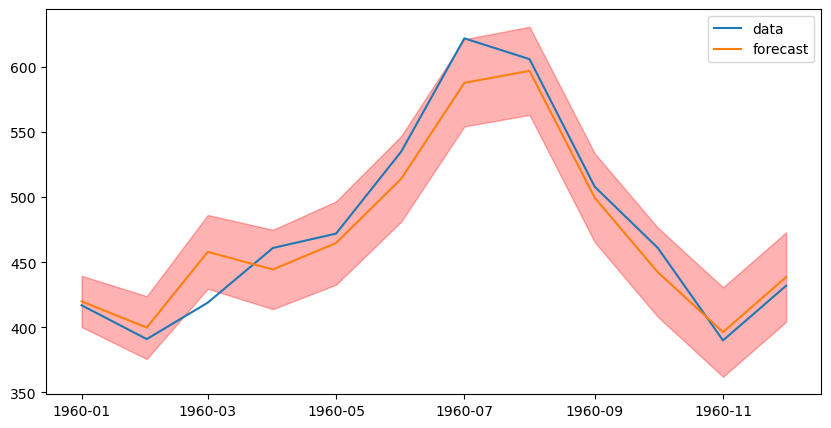

In [73]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(test.index, test['passengers'], label='data')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
               confint[:,0], confint[:,1], \
               color='red', alpha=0.3)
ax.legend();

In [74]:
def rmse(t, y):
    return np.sqrt(np.mean((t - y)**2))

In [75]:
print("Non-logged RMSE:", rmse(test['passengers'], test_pred))

Non-logged RMSE: 18.53646879692902


# SMA

In [76]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score

In [77]:
df.index.freq = 'MS'
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [78]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [79]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [80]:
hw = ExponentialSmoothing(
                        train['passengers'],
                        initialization_method='legacy-heuristic',
                        trend='add', seasonal='mul', seasonal_periods=12)
res_hw = hw.fit()

In [81]:
df.loc[train_idx, 'HoltWinterTrain'] = res_hw.fittedvalues

In [82]:
df.loc[test_idx, 'HoltWinterTest'] = res_hw.forecast(Ntest)

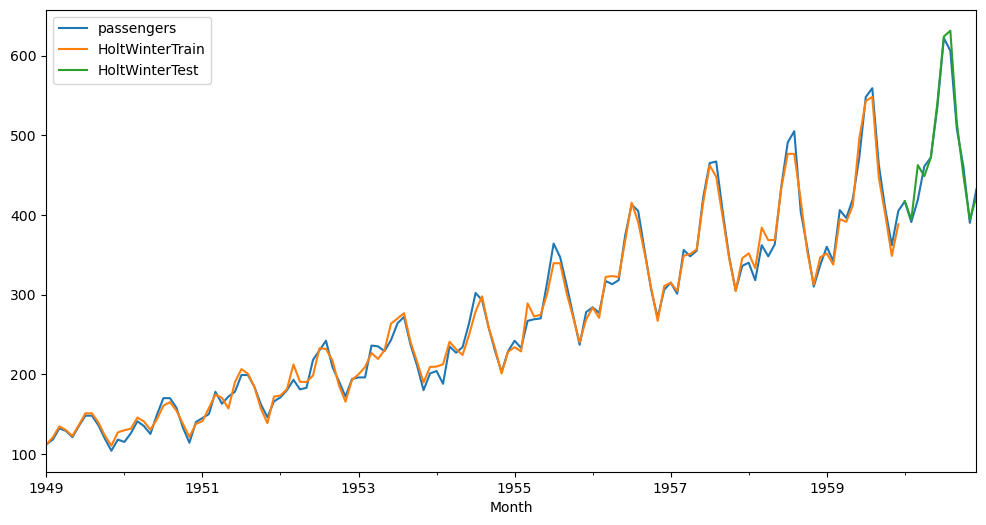

In [83]:
df[['passengers','HoltWinterTrain','HoltWinterTest']].plot(figsize=(12,6));

In [84]:
rms = res_hw.forecast(Ntest)
print(rms)

1960-01-01    417.284544
1960-02-01    394.060843
1960-03-01    462.442817
1960-04-01    448.596188
1960-05-01    471.868255
1960-06-01    539.890788
1960-07-01    623.820112
1960-08-01    631.151834
1960-09-01    515.578974
1960-10-01    449.900608
1960-11-01    394.276260
1960-12-01    422.509983
Freq: MS, dtype: float64


In [85]:
test['passengers']

Month
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: passengers, dtype: int64

In [86]:
print("ESM TEST RMSE:", rmse(test['passengers'], rms))

ESM TEST RMSE: 15.809890178532703


In [87]:
r2_score(train['passengers'] , res_hw.fittedvalues)

0.9915434901001925

In [88]:
r2_score(test['passengers'] , res_hw.forecast(Ntest))

0.9548778985740642

# FACEBOOK PROPHET

In [89]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [90]:
df.head()

,passengers,HoltWinterTrain,HoltWinterTest
Month,,,
1949-01-01,112,112.002991,NaN
1949-02-01,118,120.690529,NaN
1949-03-01,132,134.605606,NaN
1949-04-01,129,129.950178,NaN
1949-05-01,121,122.451409,NaN


In [91]:
df.drop(['HoltWinterTrain','HoltWinterTest'], axis=1, inplace=True)

In [92]:
df.columns = ['y']

In [93]:
df['ds'] = df.index

In [94]:
df.head()

,y,ds
Month,,
1949-01-01,112,1949-01-01
1949-02-01,118,1949-02-01
1949-03-01,132,1949-03-01
1949-04-01,129,1949-04-01
1949-05-01,121,1949-05-01


In [95]:
m = Prophet()
m.fit(df)

11:36:36 - cmdstanpy - INFO - Chain [1] start processing
11:36:36 - cmdstanpy - INFO - Chain [1] done processing


In [96]:
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)

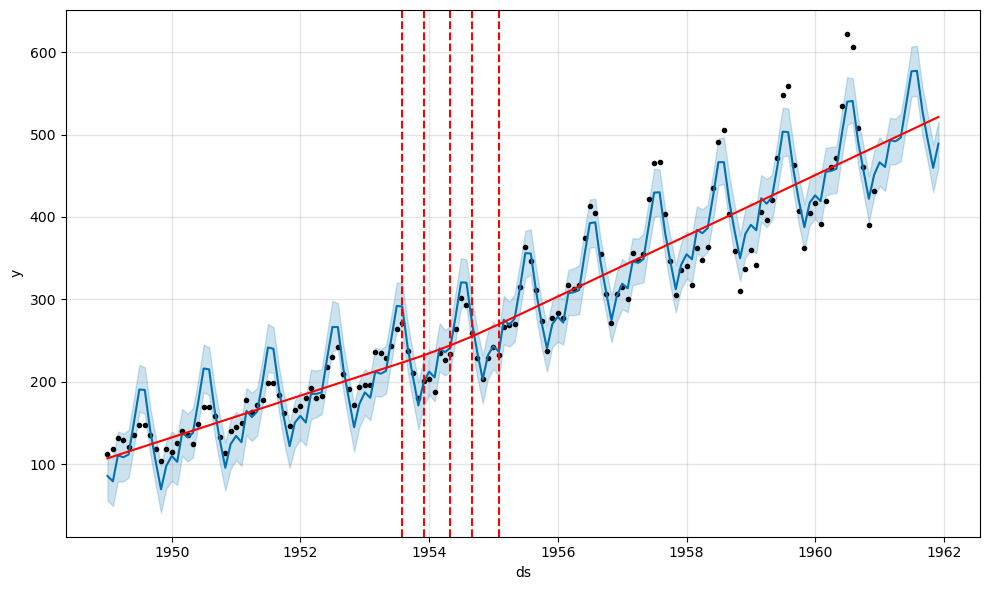

In [97]:
fig = m.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m, forecast)

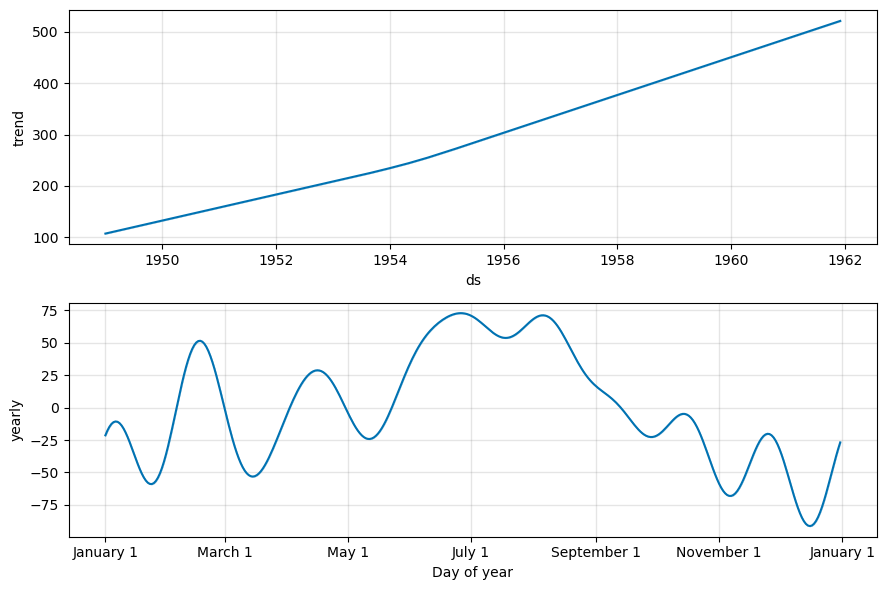

In [98]:
m.plot_components(forecast);

In [99]:
m2 = Prophet(seasonality_mode='multiplicative')
m2.fit(df)

11:36:37 - cmdstanpy - INFO - Chain [1] start processing
11:36:38 - cmdstanpy - INFO - Chain [1] done processing


In [100]:
future = m2.make_future_dataframe(periods=12, freq='MS')
forecast = m2.predict(future)

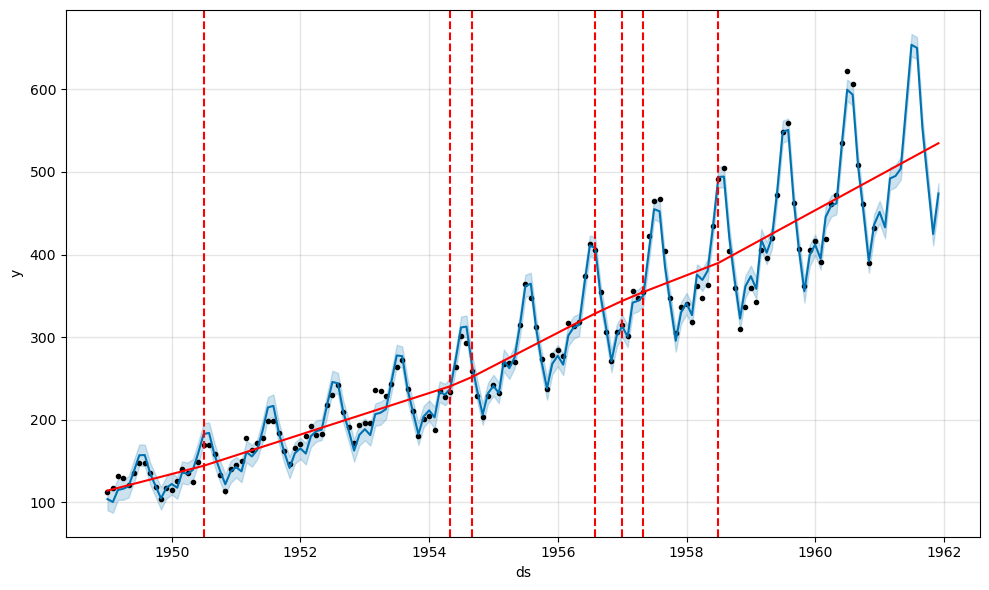

In [101]:
fig = m2.plot(forecast);
a = add_changepoints_to_plot(fig.gca(), m2, forecast)

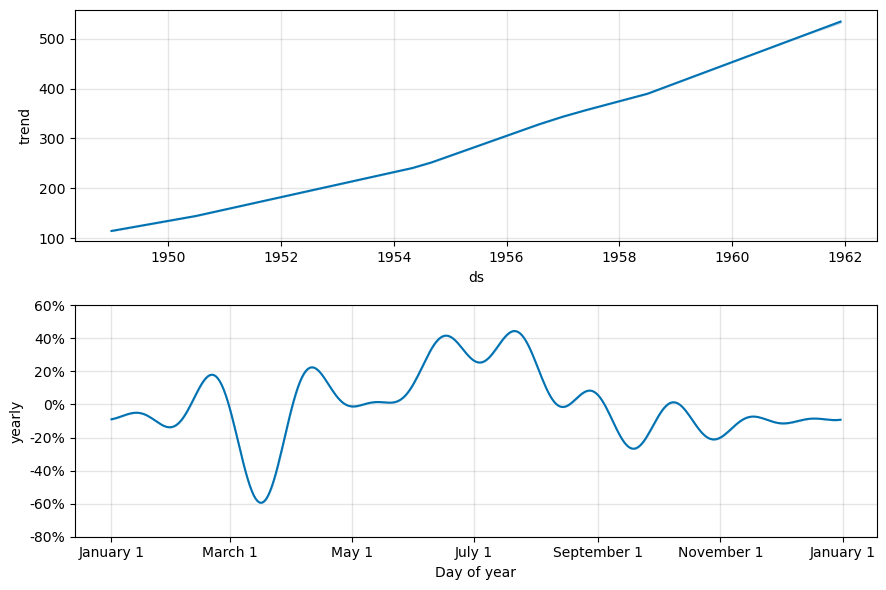

In [102]:
m2.plot_components(forecast);